# Electrum performance report (validation)

Read-only notebook over the family runs in `electrum/results/`. **No training. Test and score stay sealed.**

This is the electrum-family counterpart of [`data/quality_reports/model_performance_report.ipynb`](../../data/quality_reports/model_performance_report.ipynb). That notebook is the freeze tournament (HPO, seed bag, Platt). This one is: **one notebook per family, default knobs, val 2023 only.**

| | Path |
|---|---|
| This notebook | `electrum/results/electrum_performance.ipynb` |
| Leaderboard | `electrum/results/leaderboard.csv` |
| Freeze tournament | `data/quality_reports/model_performance_report.ipynb` |
| Freeze note | `docs/final_model_freeze.md` |

**Question:** which MISO queue projects will quit in the next 12 months?

**Rule:** train 2020–2022, pick on val 2023, do not peek at 2024 test. No 50/50 resampling. No PCA on trees. Headline score is **PR-AUC** (chance ≈ 0.041). Accuracy is a bad headline here.

## What this round actually says

**XGBoost is the only new electrum recipe near Strong.** Val PR-AUC **0.099** vs the Strong bar of **0.10** (short by 0.001). It **clears** ROC (0.767 ≥ 0.74) and MW@10% (0.281 ≥ 0.22). It **misses** log-loss (0.213 vs ≤ 0.195) and PR-lift (2.39 vs ≥ 2.5). Ranking is close; the quoted probabilities are too sloppy for Strong.

**This CatBoost run is not the freeze champion.** Electrum CatBoost used the trial-149 recipe with **deploy seed 2026** and landed at PR-AUC **0.074**. Same hyperparameters, seed 42, was **0.144** (Strong) in the retrain batch. The freeze already chose to **ship `catboost_tuned` seed 2026 + Platt** (PR-AUC **0.121** on val) because 0.144 does not repeat. Electrum just re-showed that seed gap.

**Everyone else is near a coin flip** on the rare class: Logistic, LightGBM, TabICL, NASNet, Survival sit at ~0.037–0.043 PR-AUC (chance is 0.041). FT-Transformer is 0.073 with unusable log-loss (0.81). TabPFN and TabM did not run. TimesFM is a system MW forecast, not a project-row score.

**Nothing here replaces the freeze.** Do not promote XGBoost; it misses two Strong gates. Do not treat electrum CatBoost 0.074 as evidence the recipe failed — it is the unlucky seed of a known-fragile model.

## Setup

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pio.renderers.default = "plotly_mimetype+png"

ACCENT = "#2F6FED"
GREEN = "#1B7F4E"
AMBER = "#B45309"
RED = "#B42318"
GRAY = "#6B7280"
MUTED = "#9CA3AF"

CHANCE_PR = 0.041
STRONG = {"pr_auc": 0.10, "pr_lift": 2.5, "roc_auc": 0.74, "log_loss": 0.195, "mw": 0.22}
SEED42_PR = 0.144
DEPLOY_PR = 0.121

NICE = {
    "logistic": "Logistic",
    "catboost": "CatBoost (seed 2026)",
    "lightgbm": "LightGBM",
    "xgboost": "XGBoost",
    "tabm": "TabM",
    "ft_transformer": "FT-T",
    "tabicl": "TabICL",
    "tabpfn": "TabPFN",
    "nasnet_cnn": "NASNet",
    "survival": "Survival",
    "timesfm": "TimesFM",
}

HERE = Path.cwd().resolve()
REPO = None
for p in [HERE, *HERE.parents]:
    if (p / "electrum" / "results" / "leaderboard.csv").exists():
        REPO = p
        break
if REPO is None:
    raise FileNotFoundError("Could not find electrum/results/leaderboard.csv from cwd.")

RESULTS = REPO / "electrum" / "results"
FIG = RESULTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def load_leaderboard() -> pd.DataFrame:
    df = pd.read_csv(RESULTS / "leaderboard.csv")
    for folder in RESULTS.iterdir():
        met = folder / "metrics.json"
        if not met.exists():
            continue
        m = load_json(met)
        hit = df["model"] == folder.name
        if not hit.any():
            continue
        for col in ("brier", "ece", "pr_lift", "recall_at_10pct", "rmse", "mape"):
            if col in m:
                if col not in df.columns:
                    df[col] = pd.NA
                if df.loc[hit, col].isna().all():
                    df.loc[hit, col] = m.get(col)
    df["label"] = df["model"].map(lambda m: NICE.get(str(m), str(m)))
    return df


def ok_rank(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[out["status"].astype(str) == "ok"]
    out = out[out["pr_auc"].notna()]
    return out.sort_values("pr_auc", ascending=True)


def style_fig(fig: go.Figure, *, width: int = 920, height: int = 480) -> go.Figure:
    fig.update_layout(
        template="plotly_white",
        width=width,
        height=height,
        font=dict(family="Segoe UI, Helvetica, Arial, sans-serif", size=14, color="#111827"),
        title=dict(font=dict(size=16), x=0, xanchor="left", pad=dict(t=0, b=8)),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.16,
            x=0,
            xanchor="left",
            bgcolor="rgba(0,0,0,0)",
            font=dict(size=12),
        ),
        margin=dict(l=150, r=70, t=56, b=80),
        bargap=0.28,
    )
    fig.update_xaxes(automargin=True, showgrid=True, gridcolor="#EEF2F7", zeroline=False)
    fig.update_yaxes(automargin=True, showgrid=False)
    return fig


def show(fig: go.Figure, name: str | None = None) -> None:
    if name:
        fig.write_html(FIG / name, include_plotlyjs="cdn", full_html=True)
        try:
            w = int(fig.layout.width or 920)
            h = int(fig.layout.height or 480)
            fig.write_image(FIG / Path(name).with_suffix(".png").name, width=w, height=h, scale=2)
        except Exception as e:  # noqa: BLE001
            print("png sidecar skipped:", e)
    try:
        fig.show()
    except Exception as e:  # noqa: BLE001
        print("plotly show skipped (headless):", e)
        display(fig)


def barh(fig: go.Figure, labels, values, colors, texts=None) -> None:
    fig.add_trace(
        go.Bar(
            x=values,
            y=labels,
            orientation="h",
            marker_color=colors,
            text=texts,
            textposition="outside",
            cliponaxis=False,
            hovertemplate="%{y}: %{x:.3f}<extra></extra>",
            showlegend=False,
        )
    )


def vref(fig: go.Figure, x: float, name: str, color: str, dash: str = "dash") -> None:
    fig.add_vline(x=x, line_width=1.4, line_dash=dash, line_color=color)
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            line=dict(color=color, width=1.4, dash=dash),
            name=name,
        )
    )


def gate_mark(val, kind: str) -> str:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return ""
    v = float(val)
    if kind == "pr":
        ok = v >= STRONG["pr_auc"]
    elif kind == "roc":
        ok = v >= STRONG["roc_auc"]
    elif kind == "ll":
        ok = v <= STRONG["log_loss"]
    elif kind == "mw":
        ok = v >= STRONG["mw"]
    else:
        ok = False
    return f"{v:.3f}  {'pass' if ok else 'miss'}"


lb = load_leaderboard()
ranked = ok_rank(lb)
n_train, n_val, n_test, n_score = 3277, 1666, 2204, 2676
prev_val = 0.0414

print(f"REPO     {REPO}")
print(f"Results  {RESULTS}")
print(f"Val n    {n_val:,}   prevalence {prev_val:.4f}   no-skill PR-AUC = {prev_val:.4f}")
print("Test/score sealed: True")

REPO     C:\Users\Magjun\Documents\Team-8-XternChallenge-
Results  C:\Users\Magjun\Documents\Team-8-XternChallenge-\electrum\results
Val n    1,666   prevalence 0.0414   no-skill PR-AUC = 0.0414
Test/score sealed: True


## 1. Data splits

We do **not** shuffle rows. Time moves forward. Val has far fewer quitters than train — that is the point of a calendar split.

| Split | Years | Rows | Dropout rate | Role |
|---|---|---:|---:|---|
| **Train** | 2020–2022 | 3,277 | 12.4% | Fit only |
| **Val** | 2023 | 1,666 | **4.1%** | Every number in this notebook |
| **Test** | 2024 | 2,204 | locked | Not opened |
| **Score** | 2025–2026 | 2,676 | locked | Live queue later |

**No-skill PR-AUC on val = 0.041** (the val dropout rate). Do not compare against the train rate of 0.124.

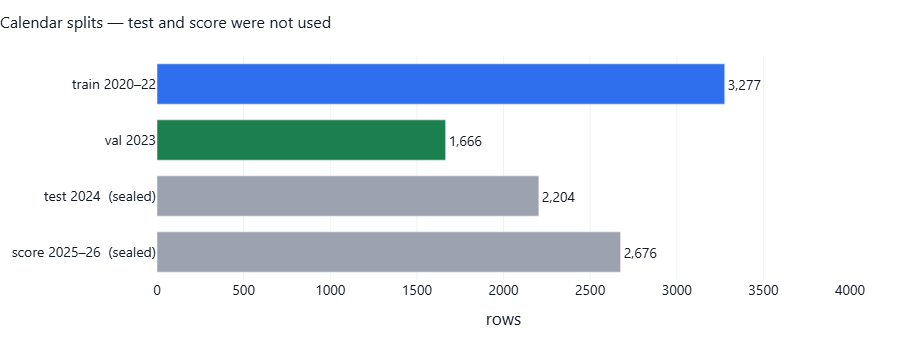

In [2]:
fig = go.Figure()
barh(
    fig,
    ["score 2025–26  (sealed)", "test 2024  (sealed)", "val 2023", "train 2020–22"],
    [n_score, n_test, n_val, n_train],
    [MUTED, MUTED, GREEN, ACCENT],
    ["2,676", "2,204", "1,666", "3,277"],
)
fig.update_layout(title="Calendar splits — test and score were not used", xaxis_title="rows")
fig.update_xaxes(range=[0, 4000])
show(style_fig(fig, height=360), "00_splits.html")

A model that memorizes 2021 interest rates will look busy on a shuffled split and fail here. Electrum LightGBM and Logistic did exactly that flavor of failure: they fit train, then sit at chance on 2023.

## 2. What the tests mean

Each project gets a **risk score**. Metrics ask different questions about that score.

| Metric | Question in plain words | Chance on this val | Strong bar |
|---|---|---|---|
| **PR-AUC** (headline) | Are the *rare* quitters near the top of the list? | **0.041** | ≥ **0.10** (~2.5× chance) |
| **PR-lift** | PR-AUC / chance | 1.0× | ≥ 2.5× |
| **ROC-AUC** | Pick one quitter and one stayer: how often does the quitter score higher? | 0.50 | ≥ 0.74 |
| **log-loss** | How painful are confident wrong answers? | — | ≤ 0.195 |
| **Precision@10%** | Of the 167 projects we flag, how many really quit? | ~4% | (no hard bar) |
| **MW@10%** | Of all *megawatts* that quit, what share is in that 10%? | ~10% if random | ≥ 0.22 |

**Why PR-AUC, not ROC or accuracy.** Quitters are 4% of val. Always predicting “stay” is ~96% accurate and finds nobody. ROC can look “pretty good” (0.7+) while you still miss most quitters. PR-AUC uses the rare class as the floor, so 0.10 vs 0.041 is the honest win.

We **rank** with PR-AUC / MW. We **quote a %** with log-loss / Brier after calibration. The freeze ships ranks from raw CatBoost and probabilities from Platt.

## 3. Model comparison (val 2023)

Headline numbers from **this electrum folder**, not from the freeze HPO dump. Roles:

| Role | Who | Why |
|---|---|---|
| Closest new method | **XGBoost** | Only run near Strong on PR-AUC |
| Electrum CatBoost | seed **2026**, trial-149 knobs | Same recipe as freeze; unlucky seed |
| Freeze paper peak (not in this folder) | CatBoost seed **42** | PR-AUC 0.144 — seed-fragile |
| Freeze deploy (not re-fit here) | `catboost_tuned` + Platt | PR-AUC 0.121 — what we ship |
| Not competitive | Logistic, LightGBM, TabICL, NASNet, Survival | ~chance |
| Weak / broken probs | FT-T | 0.073 PR-AUC, log-loss 0.81 |
| Skipped | TabPFN, TabM | no token / no `tabm` package |
| Different task | TimesFM | system MW RMSE/MAPE, not row PR-AUC |

In [3]:
rows = []
order = ["xgboost", "catboost", "ft_transformer", "tabicl", "nasnet_cnn", "survival", "lightgbm", "logistic", "timesfm", "tabpfn", "tabm"]
roles = {
    "xgboost": "closest new",
    "catboost": "electrum default (seed 2026)",
    "ft_transformer": "weak; probs unusable",
    "tabicl": "chance",
    "nasnet_cnn": "chance (2 GPU epochs)",
    "survival": "chance",
    "lightgbm": "collapsed",
    "logistic": "chance",
    "timesfm": "system forecast, not row PR-AUC",
    "tabpfn": "skipped — no TABPFN_TOKEN",
    "tabm": "skipped — tabm not installed",
}
for m in order:
    hit = lb[lb["model"] == m]
    if hit.empty:
        continue
    r = hit.iloc[0]
    rows.append(
        {
            "model": NICE.get(m, m),
            "role": roles.get(m, ""),
            "status": r["status"],
            "PR-AUC": r["pr_auc"],
            "PR-lift": r.get("pr_lift"),
            "ROC": r["roc_auc"],
            "log-loss": r["log_loss"],
            "P@10%": r["precision_at_10pct"],
            "MW@10%": r["withdrawn_mw_capture_at_10pct"],
        }
    )
view = pd.DataFrame(rows)
display(view.round(3).fillna(""))

,model,role,status,PR-AUC,PR-lift,ROC,log-loss,P@10%,MW@10%
0,XGBoost,closest new,ok,0.099,2.389,0.767,0.213,0.126,0.281
1,CatBoost (seed 2026),electrum default (seed 2026),ok,0.074,1.779,0.644,0.193,0.084,0.163
2,FT-T,weak; probs unusable,ok,0.073,1.764,0.641,0.809,0.096,0.196
3,TabICL,chance,ok,0.043,,0.496,0.353,,
4,NASNet,chance (2 GPU epochs),ok,0.043,,0.503,0.634,,
5,Survival,chance,ok,0.041,0.987,0.441,0.202,0.048,0.074
6,LightGBM,collapsed,ok,0.038,0.911,0.443,0.214,0.0,0.0
7,Logistic,chance,ok,0.037,0.894,0.468,0.292,0.024,0.045
8,TimesFM,"system forecast, not row PR-AUC",ok,,,,,,
9,TabPFN,skipped — no TABPFN_TOKEN,skipped,,,,,,


### PR-AUC — can they rank the rare quitters?

Green bars would clear Strong (≥ 0.10). Blue is “interesting but not Strong.” Grey is chance. The dotted line is a random ranking; the dashed green line is the team bar.

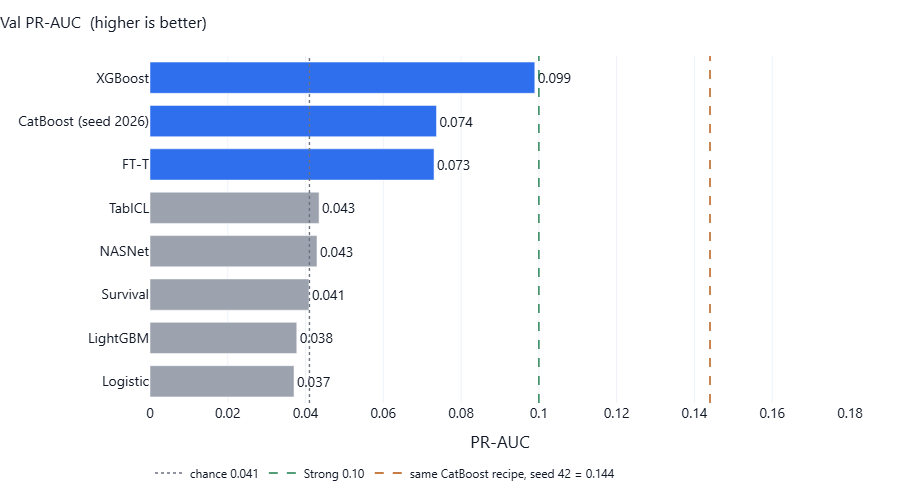

In [4]:
d = ranked
colors = [
    GREEN if float(v) >= STRONG["pr_auc"] else ACCENT if float(v) >= 0.07 else MUTED
    for v in d["pr_auc"]
]
fig = go.Figure()
barh(fig, d["label"], d["pr_auc"], colors, [f"{v:.3f}" for v in d["pr_auc"]])
vref(fig, CHANCE_PR, "chance 0.041", GRAY, "dot")
vref(fig, STRONG["pr_auc"], "Strong 0.10", GREEN, "dash")
vref(fig, SEED42_PR, "same CatBoost recipe, seed 42 = 0.144", AMBER, "dash")
fig.update_layout(title="Val PR-AUC  (higher is better)", xaxis_title="PR-AUC")
fig.update_xaxes(range=[0, 0.18])
show(style_fig(fig, height=500), "01_pr_auc.html")

**Reading the chart.** Only XGBoost reaches the neighborhood of Strong. CatBoost seed 2026 and FT-T are about 1.8× chance — better than a coin flip, far from the bar. The amber line is **not** an electrum notebook; it is the known lucky seed of the *same* CatBoost hyperparameters. If electrum CatBoost had drawn seed 42 it would sit on that line. It drew 2026, so it does not.

That is the comparison, in one sentence: **new families did not beat the freeze recipe; the freeze recipe’s own seed is noisier than the family gap.**

### Strong gates — pass / miss

Strong is all five bars, not PR-AUC alone. XGBoost looks like a near-miss until you check log-loss.

In [5]:
gate_rows = []
for m in ["xgboost", "catboost", "ft_transformer", "lightgbm", "logistic"]:
    hit = lb[lb["model"] == m]
    if hit.empty:
        continue
    r = hit.iloc[0]
    gate_rows.append(
        {
            "model": NICE.get(m, m),
            "PR-AUC ≥ 0.10": gate_mark(r["pr_auc"], "pr"),
            "ROC ≥ 0.74": gate_mark(r["roc_auc"], "roc"),
            "log-loss ≤ 0.195": gate_mark(r["log_loss"], "ll"),
            "MW@10% ≥ 0.22": gate_mark(r["withdrawn_mw_capture_at_10pct"], "mw"),
        }
    )
display(pd.DataFrame(gate_rows))

,model,PR-AUC ≥ 0.10,ROC ≥ 0.74,log-loss ≤ 0.195,MW@10% ≥ 0.22
0,XGBoost,0.099 miss,0.767 pass,0.213 miss,0.281 pass
1,CatBoost (seed 2026),0.074 miss,0.644 miss,0.193 pass,0.163 miss
2,FT-T,0.073 miss,0.641 miss,0.809 miss,0.196 miss
3,LightGBM,0.038 miss,0.443 miss,0.214 miss,0.000 miss
4,Logistic,0.037 miss,0.468 miss,0.292 miss,0.045 miss


**XGBoost:** ranking gates are close or green; honesty is red. It puts quitters near the top but quotes probabilities that are too sharp / too wrong for a 4% world.

**CatBoost seed 2026:** the one gate it *clears* is log-loss (0.193). Ranking is weak (PR-AUC 0.074, ROC 0.644, MW 0.163). This is the opposite problem from XGBoost: calmer probabilities, worse list.

**FT-T:** log-loss 0.81 is a broken probability model (worse than a constant 4% guess). Do not use the scores as “% chance of quit.”

**LightGBM / Logistic:** miss everything that matters. LightGBM’s top 10% captured **zero** quitting MW.

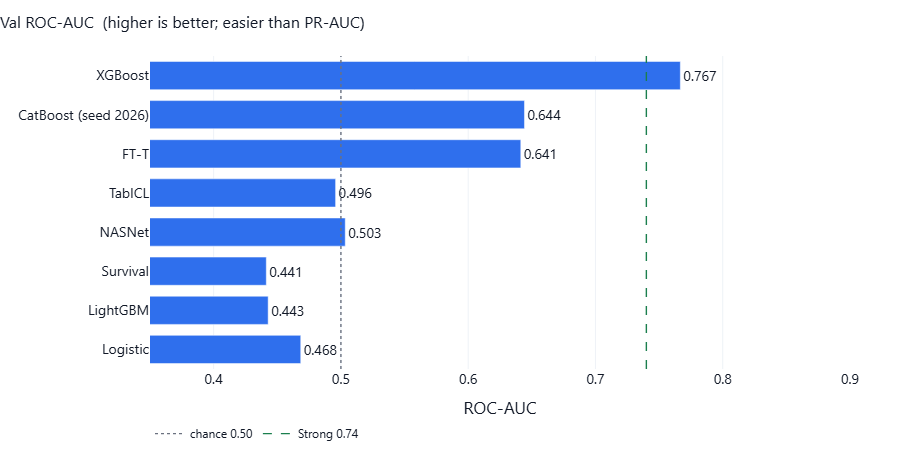

In [6]:
d = ranked
fig = go.Figure()
barh(fig, d["label"], d["roc_auc"], ACCENT, [f"{v:.3f}" if pd.notna(v) else "" for v in d["roc_auc"]])
vref(fig, 0.50, "chance 0.50", GRAY, "dot")
vref(fig, STRONG["roc_auc"], "Strong 0.74", GREEN, "dash")
fig.update_layout(title="Val ROC-AUC  (higher is better; easier than PR-AUC)", xaxis_title="ROC-AUC")
fig.update_xaxes(range=[0.35, 0.90])
show(style_fig(fig, height=460), "02_roc.html")

ROC makes XGBoost look like a clear win (0.767). That is why it is **not** the headline. Several models can separate stay vs quit a bit and still not find the rare class. Logistic and LightGBM are *below* 0.50 — worse than ranking at random.

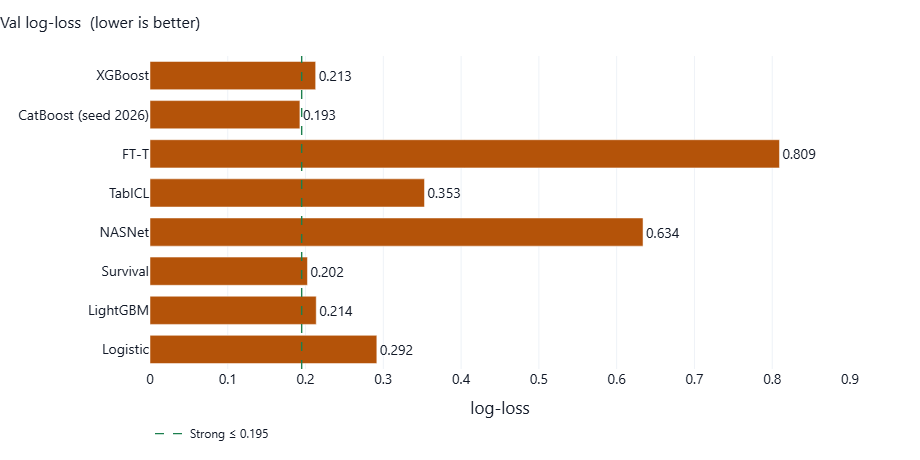

In [7]:
d = ranked
fig = go.Figure()
barh(fig, d["label"], d["log_loss"], AMBER, [f"{v:.3f}" if pd.notna(v) else "" for v in d["log_loss"]])
vref(fig, STRONG["log_loss"], "Strong ≤ 0.195", GREEN, "dash")
fig.update_layout(title="Val log-loss  (lower is better)", xaxis_title="log-loss")
fig.update_xaxes(range=[0, 0.90])
show(style_fig(fig, height=460), "02_logloss.html")

**Lower is better.** CatBoost seed 2026 is the only electrum run under 0.195. XGBoost overshoots. FT-T and NASNet are in another league of overconfidence (0.63–0.81). A constant “everyone has 4.1% chance” already has Brier ≈ 0.040; FT-T’s Brier is 0.30 — the network is not talking about this val set.

## 4. If we only watch the riskiest 10%

Val has **1,666** projects and about **69** withdrawals. Top 10% is about **167** projects. Precision 13% still means **most flagged projects stay**. This is a triage list, not a verdict.

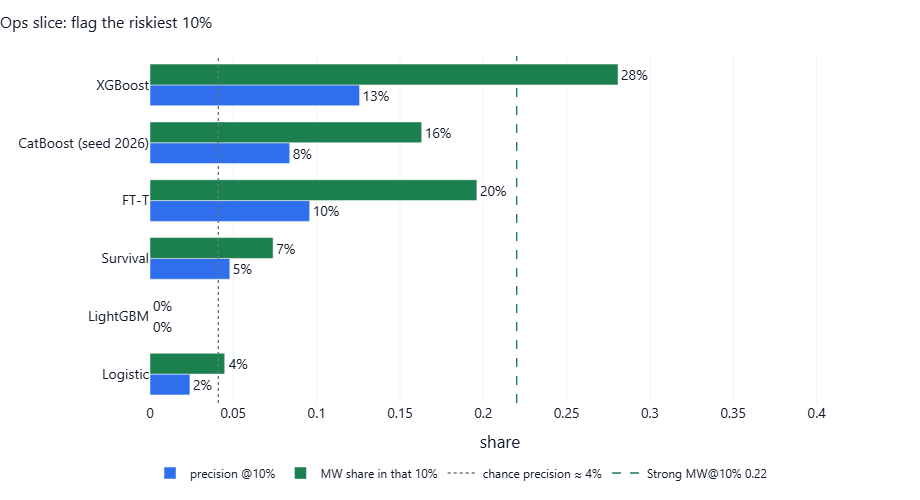

In [8]:
d = ranked[ranked["precision_at_10pct"].notna()].copy()
fig = go.Figure()
fig.add_trace(
    go.Bar(
        name="precision @10%",
        x=d["precision_at_10pct"],
        y=d["label"],
        orientation="h",
        marker_color=ACCENT,
        text=[f"{v:.0%}" for v in d["precision_at_10pct"]],
        textposition="outside",
        cliponaxis=False,
    )
)
fig.add_trace(
    go.Bar(
        name="MW share in that 10%",
        x=d["withdrawn_mw_capture_at_10pct"],
        y=d["label"],
        orientation="h",
        marker_color=GREEN,
        text=[f"{v:.0%}" for v in d["withdrawn_mw_capture_at_10pct"]],
        textposition="outside",
        cliponaxis=False,
    )
)
vref(fig, CHANCE_PR, "chance precision ≈ 4%", GRAY, "dot")
vref(fig, STRONG["mw"], "Strong MW@10% 0.22", GREEN, "dash")
fig.update_layout(title="Ops slice: flag the riskiest 10%", barmode="group", xaxis_title="share")
fig.update_xaxes(range=[0, 0.42])
show(style_fig(fig, height=500), "03_ops_at_10.html")

**XGBoost** is the only useful triage list in this folder: precision **13%** (~3× chance) and **28%** of quitting MW (clears 22%). Flag 167 projects, catch about 21 of 69 quitters and a bit over a quarter of exiting megawatts.

**CatBoost seed 2026** holds **16%** of MW — short of Strong — at 8% precision.

**LightGBM** flagged a 10% with **zero** quitters and **zero** MW. That is a failed ops rule, not a close miss.

Compare to the freeze deploy CatBoost: precision ~13% and MW ~29% on the same val idea, with honest log-loss after Platt. Electrum XGBoost matches the *ops slice* and loses on probability quality.

## 5. Train / val loops

Accuracy on these curves is not the score (always-stay is ~96% on val). What matters is whether val PR-AUC climbs toward 0.10, or val log-loss falls toward 0.195.

CatBoost logs val PR-AUC every tree. XGBoost in this run logged loss only. NASNet is two frozen GPU epochs. FT-T ran on CPU after the WSL GPU kernel died.

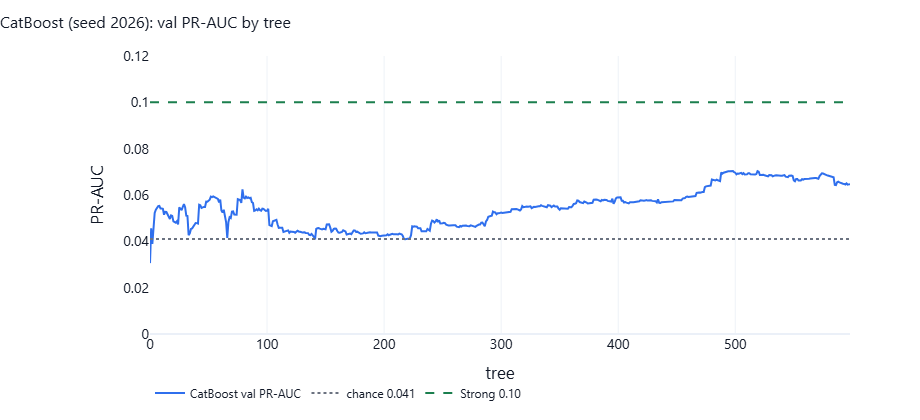

best iteration in metrics: 498


In [9]:
cb = pd.read_csv(RESULTS / "catboost" / "history.csv")
fig = go.Figure()
fig.add_trace(go.Scatter(x=cb["step"], y=cb["val_pr_auc"], mode="lines", name="CatBoost val PR-AUC", line=dict(color=ACCENT, width=2)))
fig.add_hline(y=CHANCE_PR, line_dash="dot", line_color=GRAY)
fig.add_hline(y=STRONG["pr_auc"], line_dash="dash", line_color=GREEN)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", line=dict(color=GRAY, dash="dot"), name="chance 0.041"))
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", line=dict(color=GREEN, dash="dash"), name="Strong 0.10"))
fig.update_layout(title="CatBoost (seed 2026): val PR-AUC by tree", xaxis_title="tree", yaxis_title="PR-AUC")
fig.update_yaxes(range=[0, 0.12])
show(style_fig(fig, height=420, width=920), "05_catboost_history.html")
print("best iteration in metrics:", load_json(RESULTS / "catboost" / "metrics.json").get("best_iteration"))

The curve wanders around 0.04–0.08 and never parks on Strong. Early trees are noisy; later trees do not find a 0.14 peak. That matches the seed-2026 number, not seed 42.

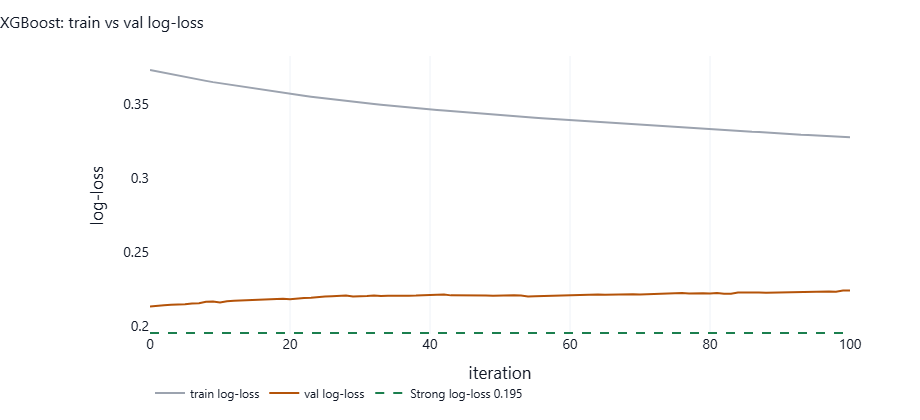

In [10]:
xgb = pd.read_csv(RESULTS / "xgboost" / "history.csv")
fig = go.Figure()
if "train_loss" in xgb.columns:
    fig.add_trace(go.Scatter(x=xgb["step"], y=xgb["train_loss"], mode="lines", name="train log-loss", line=dict(color=MUTED)))
fig.add_trace(go.Scatter(x=xgb["step"], y=xgb["val_loss"], mode="lines", name="val log-loss", line=dict(color=AMBER, width=2)))
fig.add_hline(y=STRONG["log_loss"], line_dash="dash", line_color=GREEN)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", line=dict(color=GREEN, dash="dash"), name="Strong log-loss 0.195"))
fig.update_layout(title="XGBoost: train vs val log-loss", xaxis_title="iteration", yaxis_title="log-loss")
show(style_fig(fig, height=420), "05_xgboost_history.html")

Val log-loss sits near **0.213** from the first iteration — it never crosses 0.195. The ranking (PR-AUC 0.099) is coming from order, not from well-calibrated probabilities. More trees will not fix that without a different objective / calibration step.

## 6. How close was XGBoost, really?

| Gate | Strong | XGBoost | Gap |
|------|--------|---------|-----|
| PR-AUC | ≥ 0.10 | 0.099 | short by **0.001** |
| PR-lift | ≥ 2.50 | 2.39 | short by 0.11 |
| ROC | ≥ 0.74 | 0.767 | **clears** |
| log-loss | ≤ 0.195 | 0.213 | over by **0.018** |
| MW@10% | ≥ 0.22 | 0.281 | **clears** |

A 0.001 PR-AUC gap is inside seed noise. The **disqualifying** miss is log-loss. The freeze already learned this pattern from LightGBM: good MW capture, sloppy probabilities, not the champion.

Electrum CatBoost seed 2026: PR-AUC 0.074, log-loss **0.193 (clears)**, MW 0.163 (miss). Retrain batch reminder: seed 42 = 0.144 Strong; seeds 42/123/2026 bagged = 0.097, not Strong.

## 7. What did not work

- **Logistic** — PR-AUC 0.037, ROC 0.47. Linear model on this drifted table is below chance. PLS/PCA in the retrain batch were the same.
- **LightGBM** — PR-AUC 0.038, top-10% MW = 0. The log-loss-oriented default here collapsed. (Tuned LightGBM in the *freeze* tournament was a real runner-up; this electrum run is not that model.)
- **NASNet CNN** — 2 frozen GPU epochs, PR-AUC 0.043. Matches the closed negative experiment. No more CNN budget.
- **TabICL** — ~chance. **TabPFN / TabM** — not run (API token / package missing in this kernel).
- **Survival discrete logistic** — PR-AUC 0.041 after aligning intervals to modeling val.
- **FT-Transformer** — 0.073 PR-AUC looks “not nothing,” but log-loss 0.81 and Brier 0.30 mean the probabilities are junk. CPU run after WSL GPU died; still not in the Strong neighborhood.
- **Class weights / focal** (retrain batch, not these defaults) — dumped. They quote ~25–28% when the real rate is 4%.

## 8. General observations

1. **Trees still beat everything else.** XGBoost is the only electrum family near Strong. Neural nets, the CNN, logistic, and survival are done for this table.

2. **Near-Strong ranking ≠ ship.** XGBoost’s 0.099 is a rounding error from 0.10 and a real miss on log-loss. The freeze already has a CatBoost + Platt package that clears the honesty gates.

3. **CatBoost’s 0.144 is not a deploy number.** Electrum seed 2026 = 0.074. That is the same fragility the freeze document already recorded. Ship seed 2026 + Platt; keep 0.144 in the paper appendix.

4. **Ops is triage.** Even the best list here is ~13% precision. Flag the top 10%, catch ~1 in 3 quitters / ~28% of MW, expect most flagged projects to stay.

5. **Train 12.4% vs val 4.1%.** Always score against the val base rate. Models that “remember 2020–22” fail this notebook on purpose.

6. **Test 2024 stays locked.** Opening it is a one-time freeze decision — no more knobs after that.

**One sentence:** Electrum did not find a new champion; XGBoost is a near-miss on ranking and a miss on calibration; CatBoost + Platt remains what we ship.